In [3]:
import pandas as pd

df = pd.read_csv('./data/bike_train.csv', encoding='euc-kr')
df.head()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1


In [4]:
df['holiday'].value_counts(), df['workingday'].value_counts()

(holiday
 0    10575
 1      311
 Name: count, dtype: int64,
 workingday
 1    7412
 0    3474
 Name: count, dtype: int64)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   datetime    10886 non-null  str    
 1   season      10886 non-null  int64  
 2   holiday     10886 non-null  int64  
 3   workingday  10886 non-null  int64  
 4   weather     10886 non-null  int64  
 5   temp        10886 non-null  float64
 6   atemp       10886 non-null  float64
 7   humidity    10886 non-null  int64  
 8   windspeed   10886 non-null  float64
 9   casual      10886 non-null  int64  
 10  registered  10886 non-null  int64  
 11  count       10886 non-null  int64  
dtypes: float64(3), int64(8), str(1)
memory usage: 1020.7 KB


-- 결측치 없음

-- 일자 => 공휴일, 영업일 정보가 있어 시간만 분리  2011-01-01 01:00:00
-- casual, registered 삭제 : casual + registered = count : 데이터 노출(Leak)
-- X, y 분리

In [6]:
df['hour'] = df['datetime'].str[11:13].astype('Int64')  # 시간 정보만 가져오기 => 숫자화

df.head(20)

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,hour
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0000,3,13,16,0
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0000,8,32,40,1
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0000,5,27,32,2
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0000,3,10,13,3
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0000,0,1,1,4
5,2011-01-01 05:00:00,1,0,0,2,9.84,12.880,75,6.0032,0,1,1,5
6,2011-01-01 06:00:00,1,0,0,1,9.02,13.635,80,0.0000,2,0,2,6
7,2011-01-01 07:00:00,1,0,0,1,8.20,12.880,86,0.0000,1,2,3,7
8,2011-01-01 08:00:00,1,0,0,1,9.84,14.395,75,0.0000,1,7,8,8
9,2011-01-01 09:00:00,1,0,0,1,13.12,17.425,76,0.0000,8,6,14,9


In [7]:
df['hour'] = df['datetime'].str[11:13].astype('Int64')  # 시간 정보만 가져오기 => 숫자화
y = df['count']
X = df.drop(columns=['datetime','count', 'casual', 'registered'])
X.head()

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,hour
0,1,0,0,1,9.84,14.395,81,0.0,0
1,1,0,0,1,9.02,13.635,80,0.0,1
2,1,0,0,1,9.02,13.635,80,0.0,2
3,1,0,0,1,9.84,14.395,75,0.0,3
4,1,0,0,1,9.84,14.395,75,0.0,4


In [8]:
y.head()

0    16
1    40
2    32
3    13
4     1
Name: count, dtype: int64

In [9]:
y.describe()

count    10886.000000
mean       191.574132
std        181.144454
min          1.000000
25%         42.000000
50%        145.000000
75%        284.000000
max        977.000000
Name: count, dtype: float64

(array([4284., 2337., 1686., 1067.,  633.,  426.,  233.,  116.,   85.,
          19.]),
 array([  1. ,  98.6, 196.2, 293.8, 391.4, 489. , 586.6, 684.2, 781.8,
        879.4, 977. ]),
 <BarContainer object of 10 artists>)

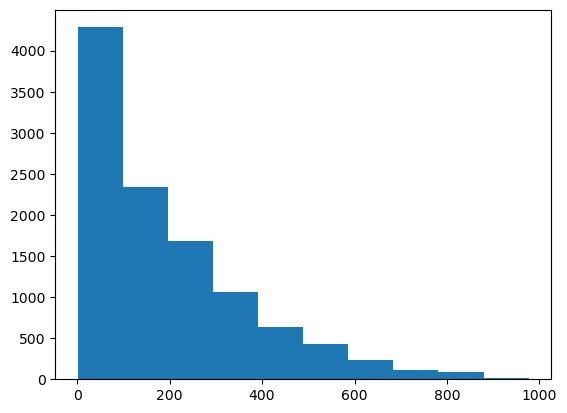

In [10]:
from matplotlib import pyplot as plt

plt.hist(y)

-- train, test 분리  
-- scaling

In [11]:
# Data 분리 및 Scaling
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

# Predict After Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [25]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

def get_model_performance(real, pred) :
    
    mae = mean_absolute_error(real, pred)
    rmse = np.sqrt(mean_squared_error(real, pred))
    r2 = r2_score(real, pred)
    
    print(f"R-Square Score : {r2:.3f}")
    print(f"Real(Test) Value Mean : {real.mean():,.1f}, Mean-Square-Root Error : {rmse:,.1f}")
    print(f"Mean Absolute Error : {mae:.3f}")
    
    return r2, rmse 

In [13]:
# 학습모델 선정 및 최적화
from sklearn.linear_model import LinearRegression

# 선형회귀모델 : 정의 및 학습
model_linear = LinearRegression()
# model_linear.fit(X_train, y_train)
model_linear.fit(X_train_scaled, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [14]:
# y_pred = model_linear.predict(X_test)
y_pred = model_linear.predict(X_test_scaled)

r2, rmse = get_model_performance(y_test, y_pred)

float(rmse), r2

Mean Absolute Error : 109.981
R-Square Score : 0.331
Real(Test) Value Mean : 194.4, Mean-Square-Root Error : 149.1


(149.1322192163028, 0.330628967052378)

# LASSO Model

In [15]:
# 학습모델 선정 및 최적화
from sklearn.linear_model import Lasso

# alpha 값을 조정하며 변수가 얼마나 0이 되는지 확인하는 것이 포인트입니다.
model_lasso = Lasso(alpha=0.1, max_iter=1000)
model_lasso.fit(X_train, y_train)

# 학습에 사용된 컬럼명 리스트 (X_train이 DataFrame인 경우)
feature_names = X_train.columns

# 가중치가 0이 아닌 인덱스만 추출하여 데이터프레임 생성
used_features = pd.DataFrame({
    'feature': feature_names,
    'coef': model_lasso.coef_
})

# 가중치가 0이 아닌 변수들만 필터링
selected_features = used_features[used_features['coef'] != 0]

print("Lasso가 선택한 변수 목록:")
print(selected_features)

print("Lasso가 제거한 변수 목록:")
print(used_features[used_features['coef'] == 0])

Lasso가 선택한 변수 목록:
      feature       coef
0      season  22.470011
1     holiday  -6.379753
2  workingday   1.319191
3     weather  -3.313137
4        temp   2.969149
5       atemp   3.724737
6    humidity  -2.252005
7   windspeed   0.148644
8        hour   7.625352
Lasso가 제거한 변수 목록:
Empty DataFrame
Columns: [feature, coef]
Index: []


In [16]:
# y_pred = model_linear.predict(X_test)
y_pred = model_lasso.predict(X_test_scaled)

r2, rmse = get_model_performance(y_test, y_pred)

Mean Absolute Error : 162.683
R-Square Score : -0.617
Real(Test) Value Mean : 194.4, Mean-Square-Root Error : 231.8


c:\Apps\MiniConda\envs\ml_edu\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but Lasso was fitted with feature names
  warnings.warn(


# Lasso with y-value Log-Scaling

In [40]:
# 학습모델 선정 및 최적화
from sklearn.linear_model import Lasso
from sklearn.compose import TransformedTargetRegressor
from sklearn.model_selection import GridSearchCV

# 1. 기본 모델 설정
model_lasso_base = Lasso(random_state=42, max_iter=10000)

# 2. 로그 변환을 포함한 Regressor 생성
model_lasso_tt = TransformedTargetRegressor(
    regressor=model_lasso_base,
    func=np.log1p, 
    inverse_func=np.expm1
)

# 3. 하이퍼파라미터 그리드 설정
# Lasso에서 가장 중요한 파라미터는 규제 강도를 조절하는 alpha입니다.
param_grid = {
    'regressor__alpha': [0.001, 0.01, 0.1, 1, 10, 100]
}

# 4. GridSearchCV 객체 생성
grid_search_lasso = GridSearchCV(
    model_lasso_tt, 
    param_grid, 
    cv=5, 
    scoring='r2', 
    n_jobs=-1, 
    verbose=1
)

# 5. 학습 및 최적의 파라미터 확인
grid_search_lasso.fit(X_train_scaled, y_train)

# 6. 결과 확인
print(f"최적 파라미터: {grid_search_lasso.best_params_}")
print(f"최고 R2 점수 (CV): {grid_search_lasso.best_score_:.4f}")

# 7. 최적의 모델 추출
model_lasso_opt = grid_search_lasso.best_estimator_

# 학습에 사용된 컬럼명 리스트 (X_train이 DataFrame인 경우)
feature_names = X_train.columns

# 가중치가 0이 아닌 인덱스만 추출하여 데이터프레임 생성
used_features = pd.DataFrame({
    'feature': feature_names,
    'coef': model_lasso_opt.regressor_.coef_
})

# 가중치가 0이 아닌 변수들만 필터링
selected_features = used_features[used_features['coef'] != 0]

print("Lasso가 선택한 변수 목록:")
print(selected_features)

print("Lasso가 제거한 변수 목록:")
print(used_features[used_features['coef'] == 0])

Fitting 5 folds for each of 6 candidates, totalling 30 fits
최적 파라미터: {'regressor__alpha': 0.01}
최고 R2 점수 (CV): 0.1653
Lasso가 선택한 변수 목록:
      feature      coef
0      season  0.196051
1     holiday -0.000404
2  workingday -0.021801
4        temp  0.130536
5       atemp  0.225834
6    humidity -0.290814
7   windspeed  0.016655
8        hour  0.664747
Lasso가 제거한 변수 목록:
   feature  coef
3  weather  -0.0


In [53]:
# y_pred = model_linear.predict(X_test)
y_pred = model_lasso_opt.predict(X_test_scaled)

r2, rmse = get_model_performance(y_test, y_pred)

R-Square Score : 0.145
Real(Test) Value Mean : 194.4, Mean-Square-Root Error : 168.6
Mean Absolute Error : 112.962


# Ridge Model

In [20]:
# 학습모델 선정 및 최적화
from sklearn.linear_model import Ridge, RidgeCV

# 설정한 alpha 범위 내에서 교차 검증 수행
alphas = [0.01, 0.1, 1.0, 10.0, 100.0]
ridge_cv = RidgeCV(alphas=alphas, cv=5)
ridge_cv.fit(X_train_scaled, y_train)

# 최적의 alpha 값 확인
best_alpha = ridge_cv.alpha_
print(f"Best Alpha: {best_alpha}")

# alpha 값을 조정하며 변수가 얼마나 0이 되는지 확인하는 것이 포인트입니다.
model_ridge = Lasso(alpha=best_alpha) # best_alpha from RidgeCV
model_ridge.fit(X_train_scaled, y_train)

Best Alpha: 100.0


,"alpha alpha: float, default=1.0Constant that multiplies the L1 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Lasso` object is not advised.Instead, you should use the :class:`LinearRegression` object.",np.float64(100.0)
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.",False
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=1000The maximum number of iterations.",1000
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``, see Notes below.",0.0001
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fit asinitialization, otherwise, just erase the previous solution.See :term:`the Glossary `.",False
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.",False
,"random_state random_state: int, RandomState instance, default=NoneThe seed of the pseudo random number generator that selects a randomfeature to update. Used when ``selection`` == 'random'.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",None
,"selection selection: {'cyclic', 'random'}, default='cyclic'If set to 'random', a random coefficient is updated every iterationrather than looping over features sequentially by default. This(setting to 'random') often leads to significantly faster convergenceespecially when tol is higher than 1e-4.",'cyclic'


In [22]:
# y_pred = model_linear.predict(X_test)
y_pred = model_lasso.predict(X_test_scaled)

r2, rmse = get_model_performance(y_test, y_pred)

Mean Absolute Error : 162.683
R-Square Score : -0.617
Real(Test) Value Mean : 194.4, Mean-Square-Root Error : 231.8


c:\Apps\MiniConda\envs\ml_edu\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but Lasso was fitted with feature names
  warnings.warn(


# 2차 다항식(Polynomial Features) + Log Scaling of y

In [54]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.compose import TransformedTargetRegressor
from sklearn.linear_model import Ridge, RidgeCV

# 1. X 데이터 처리를 위한 파이프라인 (스케일링 없이 2차항만 적용, 이전 단계에서 적용)
# include_bias=False는 상수항(1)을 추가하지 않겠다는 설정입니다 (Ridge에서 자동으로 처리 가능)
x_poly_pipeline = Pipeline([
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('ridge_cv', RidgeCV(alphas=np.logspace(-3, 3, 10), cv=5))
])

# 2. y값 로그 변환을 포함한 통합 모델 설정
# func=np.log1p: 학습 시 y에 로그를 취함
# inverse_func=np.expm1: 예측 시 원래 단위로 복원함
model_poly_ridge = TransformedTargetRegressor(
    regressor=x_poly_pipeline,
    func=np.log1p,
    inverse_func=np.expm1
)

# 3. 모델 학습
# X_train은 변환 전 원본, y_train도 변환 전 원본을 그대로 넣습니다.
model_poly_ridge.fit(X_train_scaled, y_train)

best_alpha = model_poly_ridge.regressor_.named_steps['ridge_cv'].alpha_
print(f"최적의 Alpha: {best_alpha}")

최적의 Alpha: 10.0


In [56]:
# 1. 2차항 변환기(PolynomialFeatures)와 학습된 Ridge 모델 추출
poly_transformer = model_poly_ridge.regressor_.named_steps['poly']
ridge_model = model_poly_ridge.regressor_.named_steps['ridge_cv']

# 2. 확장된 피처 이름 생성 
# (원본 feature_names 리스트가 필요합니다. 예: ['temp', 'humid'])
poly_feature_names = poly_transformer.get_feature_names_out(feature_names)

# 3. 계수(Coefficients) 추출
# RidgeCV는 선형 모델이므로 coef_를 통해 기여도를 확인합니다.
weights = ridge_model.coef_

# 4. 데이터프레임 생성 및 정렬
feature_contribution = pd.DataFrame({
    'Feature': poly_feature_names,
    'Weight': weights
})

# 5. 영향력(절댓값) 기준 내림차순 정렬
feature_contribution['Abs_Weight'] = feature_contribution['Weight'].abs()
feature_contribution = feature_contribution.sort_values(by='Abs_Weight', ascending=False)

print("--- 2차항 확장 피처별 기여도 (Top 10) ---")
print(feature_contribution[['Feature', 'Weight']].head(10))

--- 2차항 확장 피처별 기여도 (Top 10) ---
            Feature    Weight
8              hour  0.711704
53           hour^2 -0.578048
4              temp  0.400657
39           temp^2 -0.226950
6          humidity -0.190382
44          atemp^2  0.185176
41    temp humidity -0.179868
45   atemp humidity  0.158606
28  workingday temp -0.148501
32  workingday hour  0.138718


In [26]:
np.logspace(-3, 3, 10)

array([1.00000000e-03, 4.64158883e-03, 2.15443469e-02, 1.00000000e-01,
       4.64158883e-01, 2.15443469e+00, 1.00000000e+01, 4.64158883e+01,
       2.15443469e+02, 1.00000000e+03])

In [55]:
# 4. 결과 확인
y_pred = model_poly_ridge.predict(X_test_scaled)

r2, rmse = get_model_performance(y_test, y_pred)

R-Square Score : 0.450
Real(Test) Value Mean : 194.4, Mean-Square-Root Error : 135.2
Mean Absolute Error : 84.062


In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV


model_rfr = RandomForestRegressor(random_state=42, n_jobs=-1)

# 학습용 문제와 정답을 주고 모델 학습시키기
param_grid = {
    'n_estimators': [100, 200, 300],         # 트리 개수 (많을수록 안정적이나 300 이상은 효율 저하 가능)
    'max_depth': [None, 10, 20, 30],         # 트리 최대 깊이 (None은 끝까지 분할, 10~20은 과적합 방지용)
    'min_samples_split': [2, 5, 10],         # 노드 분할을 위한 최소 샘플 수 (데이터 1% 내외인 10까지 권장)
    'min_samples_leaf': [1, 2, 4],           # 리프 노드가 되기 위한 최소 샘플 수
    'max_features': ['sqrt', 'log2', None]   # 각 노드 분할 시 고려할 특성 수 (None은 전체 특성 사용)
}

# 3. GridSearchCV 객체 생성 (5-fold 교차 검증 사용)
grid_search = GridSearchCV(model_rfr, param_grid, cv=5, scoring='r2', n_jobs=-1, verbose=1)

# 4. 학습 (X_train, y_train은 앞서 변환한 NumPy 배열)
grid_search.fit(X_train_scaled, y_train)

# 5. 최적의 결과 확인
print(f"최적 파라미터: {grid_search.best_params_}")
print(f"최고 정확도: {grid_search.best_score_:.4f}")

# 6. 최적의 모델 추출
model_rfr = grid_search.best_estimator_

# Random Forrest Model with y-value log-scaling

In [29]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.compose import TransformedTargetRegressor # 타겟 변환용

# 1. 기본 모델 설정
model_rfr_base = RandomForestRegressor(random_state=42, n_jobs=-1)

# 2. 로그 변환을 포함한 Regressor 생성
# func=np.log1p는 학습 시 로그를 취하고, inverse_func=np.expm1은 예측 시 복원합니다.
model_rfr_tt = TransformedTargetRegressor(regressor=model_rfr_base, 
                                      func=np.log1p, 
                                      inverse_func=np.expm1)

# 학습용 문제와 정답을 주고 모델 학습시키기
# 3. 하이퍼파라미터 그리드 수정
# TransformedTargetRegressor를 사용할 때는 파라미터 이름 앞에 'regressor__'를 붙여야 합니다.
param_grid = {
    'regressor__n_estimators': [100, 200, 300],         # 트리 개수 (많을수록 안정적이나 300 이상은 효율 저하 가능)
    'regressor__max_depth': [None, 10, 20, 30],         # 트리 최대 깊이 (None은 끝까지 분할, 10~20은 과적합 방지용)
    'regressor__min_samples_split': [2, 5, 10],         # 노드 분할을 위한 최소 샘플 수 (데이터 1% 내외인 10까지 권장)
    'regressor__min_samples_leaf': [1, 2, 4],           # 리프 노드가 되기 위한 최소 샘플 수
    'regressor__max_features': ['sqrt', 'log2', None]   # 각 노드 분할 시 고려할 특성 수 (None은 전체 특성 사용)
}

# 3. GridSearchCV 객체 생성 (5-fold 교차 검증 사용)
grid_search = GridSearchCV(model_rfr_tt, param_grid, cv=5, scoring='r2', n_jobs=-1, verbose=1)

# 4. 학습 (X_train, y_train은 앞서 변환한 NumPy 배열)
grid_search.fit(X_train_scaled, y_train)

# 5. 최적의 결과 확인
print(f"최적 파라미터: {grid_search.best_params_}")
print(f"최고 정확도: {grid_search.best_score_:.4f}")

# 6. 최적의 모델 추출
model_rfr_opt = grid_search.best_estimator_

Fitting 5 folds for each of 324 candidates, totalling 1620 fits
최적 파라미터: {'regressor__max_depth': 20, 'regressor__max_features': None, 'regressor__min_samples_leaf': 2, 'regressor__min_samples_split': 2, 'regressor__n_estimators': 200}
최고 정확도: 0.8423


In [50]:
# 1. 최적의 모델(model_rfr_opt) 내부에서 실제 RandomForest 객체에 접근
# TransformedTargetRegressor를 사용했으므로 .regressor_를 통해 접근합니다.
# 2. 특성 중요도 가져오기
importances = model_rfr_opt.regressor_.feature_importances_

# 3. 특성 이름과 매칭 (feature_names 변수가 필요함)
# feature_names가 없다면: feature_names = [f'Features_{i}' for i in range(X_train_scaled.shape[1])]
rf_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})

# 4. 중요도 순으로 내림차순 정렬
rf_importance_df = rf_importance_df.sort_values(by='Importance', ascending=False)

# 5. 결과 출력
print("Top 10 핵심 요소:")
print(rf_importance_df)

Top 10 핵심 요소:
      Feature  Importance
8        hour    0.575868
2  workingday    0.160452
0      season    0.068831
5       atemp    0.050007
4        temp    0.043063
3     weather    0.035032
6    humidity    0.031106
1     holiday    0.021726
7   windspeed    0.013917


In [51]:
from sklearn.ensemble import RandomForestRegressor

# ==========================================
# 학습 후 예측 및 평가
# ==========================================
# 학습에 사용하지 않은 테스트용 문제(X_test)를 주고 예측해보기
model_rfr_opt.fit(X_train_scaled, y_train)
y_pred = model_rfr_opt.predict(X_test_scaled)

# 실제 정답(y_test)과 모델이 예측한 값(y_pred)을 비교하여 정확도 계산
r2, rmse = get_model_performance(y_test, y_pred)

R-Square Score : 0.859
Real(Test) Value Mean : 194.4, Mean-Square-Root Error : 68.5
Mean Absolute Error : 44.699


# XGBRegressor

In [33]:
from xgboost import XGBRegressor


# 1. 기본 모델 설정
model_xgb_base = XGBRegressor(random_state=42, n_jobs=-1, verbosity=0)

# 2. 로그 변환을 포함한 Regressor 생성
# func=np.log1p는 학습 시 로그를 취하고, inverse_func=np.expm1은 예측 시 복원합니다.
model_xgb_tt = TransformedTargetRegressor(regressor=model_xgb_base, 
                                      func=np.log1p, 
                                      inverse_func=np.expm1)

# 학습용 문제와 정답을 주고 모델 학습시키기
# 3. 하이퍼파라미터 그리드 설정
# XGBoost의 핵심 파라미터들로 구성
param_grid = {
    'regressor__n_estimators': [100, 200, 300],
    'regressor__learning_rate': [0.01, 0.05, 0.1], # 학습률
    'regressor__max_depth': [3, 5, 7],             # 트리 깊이 (너무 깊으면 과적합 위험)
    'regressor__subsample': [0.7, 0.8, 0.9],       # 각 트리 학습 시 샘플링 비율
    'regressor__colsample_bytree': [0.7, 0.8, 0.9] # 각 트리 학습 시 피처 사용 비율
}

# 3. GridSearchCV 객체 생성 (5-fold 교차 검증 사용)
grid_search_xgb = GridSearchCV(model_xgb_tt, param_grid, cv=5, scoring='r2', n_jobs=-1, verbose=1)

# 4. 학습 (X_train, y_train은 앞서 변환한 NumPy 배열)
grid_search_xgb.fit(X_train_scaled, y_train)

# 5. 최적의 결과 확인
print(f"최적 파라미터: {grid_search_xgb.best_params_}")
print(f"최고 정확도: {grid_search_xgb.best_score_:.4f}")

# 6. 최적의 모델 추출
model_xgb_opt = grid_search_xgb.best_estimator_

Fitting 5 folds for each of 243 candidates, totalling 1215 fits
최적 파라미터: {'regressor__colsample_bytree': 0.9, 'regressor__learning_rate': 0.05, 'regressor__max_depth': 7, 'regressor__n_estimators': 300, 'regressor__subsample': 0.7}
최고 정확도: 0.8604


In [57]:
# 1. 최적의 모델(model_rfr_opt) 내부에서 실제 RandomForest 객체에 접근
# TransformedTargetRegressor를 사용했으므로 .regressor_를 통해 접근합니다.
# 2. 특성 중요도 가져오기
importances = model_xgb_opt.regressor_.feature_importances_

# 3. 특성 이름과 매칭 (feature_names 변수가 필요함)
# feature_names가 없다면: feature_names = [f'Features_{i}' for i in range(X_train_scaled.shape[1])]
rf_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})

# 4. 중요도 순으로 내림차순 정렬
rf_importance_df = rf_importance_df.sort_values(by='Importance', ascending=False)

# 5. 결과 출력
print("Top 10 핵심 요소:")
print(rf_importance_df)

Top 10 핵심 요소:
      Feature  Importance
8        hour    0.575868
2  workingday    0.160452
0      season    0.068831
5       atemp    0.050007
4        temp    0.043063
3     weather    0.035032
6    humidity    0.031106
1     holiday    0.021726
7   windspeed    0.013917


In [35]:
# ==========================================
# 학습 후 예측 및 평가
# ==========================================
# 학습에 사용하지 않은 테스트용 문제(X_test)를 주고 예측해보기
model_xgb_opt.fit(X_train_scaled, y_train)
y_pred = model_xgb_opt.predict(X_test_scaled)

# 실제 정답(y_test)과 모델이 예측한 값(y_pred)을 비교하여 정확도 계산
r2, rmse = get_model_performance(y_test, y_pred)

R-Square Score : 0.859
Real(Test) Value Mean : 194.4, Mean-Square-Root Error : 68.5
Mean Absolute Error : 44.699


# Decision Tree with Log-Scaling

In [46]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.compose import TransformedTargetRegressor

# 1. 기본 모델 설정
model_dt_base = DecisionTreeRegressor(random_state=42)

# 2. 로그 변환을 포함한 Regressor 생성
model_dt_tt = TransformedTargetRegressor(
    regressor=model_dt_base,
    func=np.log1p, 
    inverse_func=np.expm1
)

# 3. 하이퍼파라미터 그리드 설정
param_grid = {
    'regressor__max_depth': [None, 5, 10, 20],       # 트리의 최대 깊이
    'regressor__min_samples_split': [2, 5, 10],    # 노드 분할을 위한 최소 샘플 수
    'regressor__min_samples_leaf': [1, 2, 4],       # 리프 노드의 최소 샘플 수
    'regressor__max_features': [None, 'sqrt', 'log2'] # 분할 시 고려할 특성 수
}

# 4. GridSearchCV 객체 생성
grid_search_dt = GridSearchCV(
    model_dt_tt, 
    param_grid, 
    cv=5, 
    scoring='r2', 
    n_jobs=-1, 
    verbose=1
)

# 5. 학습 (X_train_scaled와 y_train 사용)
grid_search_dt.fit(X_train_scaled, y_train)

# 6. 최적의 모델 추출
best_model_dt = grid_search_dt.best_estimator_

# 7. 특성 중요도(Feature Importance) 확인
# 결정 트리는 coef_ 대신 feature_importances_를 사용합니다.
importances = best_model_dt.regressor_.feature_importances_
feature_importance_df = pd.DataFrame({
    'Feature': feature_names, # 미리 정의된 컬럼명 리스트
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print(f"최적 파라미터: {grid_search_dt.best_params_}")
print(f"최고 R2 점수: {grid_search_dt.best_score_:.4f}")
print("\n[특성 중요도")
print(feature_importance_df)

Fitting 5 folds for each of 108 candidates, totalling 540 fits
최적 파라미터: {'regressor__max_depth': 10, 'regressor__max_features': None, 'regressor__min_samples_leaf': 4, 'regressor__min_samples_split': 10}
최고 R2 점수: 0.7873

[특성 중요도
      Feature  Importance
8        hour    0.812767
4        temp    0.056238
2  workingday    0.052970
0      season    0.035569
6    humidity    0.020069
3     weather    0.009578
5       atemp    0.005787
7   windspeed    0.005469
1     holiday    0.001553


In [47]:
# ==========================================
# 학습 후 예측 및 평가
# ==========================================
# 학습에 사용하지 않은 테스트용 문제(X_test)를 주고 예측해보기
# best_model_dt.fit(X_train_scaled, y_train)
y_pred = best_model_dt.predict(X_test_scaled)

# 실제 정답(y_test)과 모델이 예측한 값(y_pred)을 비교하여 정확도 계산
r2, rmse = get_model_performance(y_test, y_pred)

R-Square Score : 0.774
Real(Test) Value Mean : 194.4, Mean-Square-Root Error : 86.6
Mean Absolute Error : 55.316
